In [2]:
%cd ..
from app.data_providers import get_shots_dataframe, main_dataframe, filtered_shots_dataframe
from app.config import TARGET_VARIABLE
from processing.helpers import shot_accuracy_by_fields
%cd notebooks

/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions
/home/soeren/Documents/Liora/NBA_Project/nba_shot_predictions/notebooks


In [3]:
df = main_dataframe()



Repo card metadata block was not found. Setting CardData to empty.


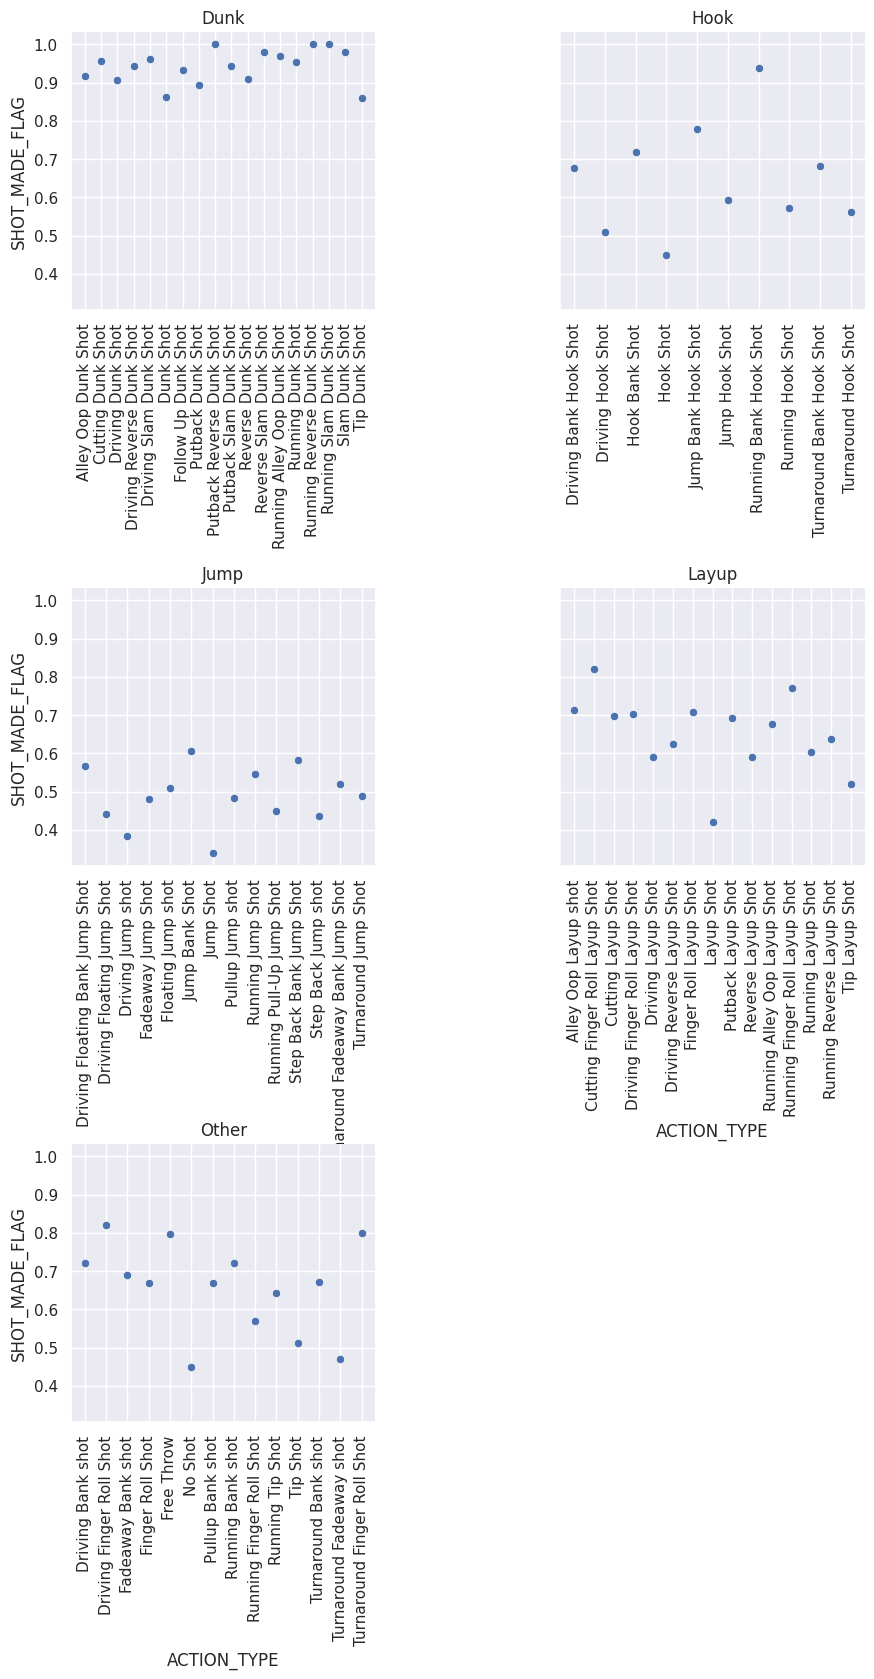

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_accuracy = shot_accuracy_by_fields(df, ['MAIN_ACTION_TYPE', 'ACTION_TYPE']).reset_index()

# g = sns.FacetGrid(df_accuracy, col="MAIN_ACTION_TYPE", col_wrap=1)

# g.map_dataframe(
#     sns.barplot,
#     x='ACTION_TYPE',
#     y=TARGET_VARIABLE
# )

sns.set()

graph = sns.relplot(data = df_accuracy, x = "ACTION_TYPE", y = TARGET_VARIABLE, 
                    col = "MAIN_ACTION_TYPE", col_wrap=2,
                    facet_kws = dict(sharex=False)).set_xticklabels(rotation=90)
graph.fig.subplots_adjust(hspace=1)
graph.set_titles(col_template = '{col_name}')

# for ax in graph.axes.flat:
#     labels = ax.get_xticklabels() # get x labels
#     ax.xticks(rotation=75) # set new labels



plt.show()

The fine categorizing of the action type induces a leak: Not further categorized shots as "Layup Shot", "Jump Shot" or "Hook Shot" are significantly less succesful, although there is no reason to assume that they are more difficult. It seems the categorizing mechanism has a bias towards not further categorizing missed shots into detailed categories. 

## ANOVA TEST

In [5]:
import statsmodels.api
result = statsmodels.formula.api.ols('SHOT_MADE_FLAG ~ MAIN_ACTION_TYPE', data=df_accuracy).fit()
table = statsmodels.api.stats.anova_lm(result)
display(table)

,df,sum_sq,mean_sq,F,PR(>F)
MAIN_ACTION_TYPE,4.0,1.775665,0.443916,48.031711,7.278718e-19
Residual,66.0,0.609982,0.009242,NaN,NaN
